In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"

In [7]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month

In [8]:
df.replace(-999, np.nan, inplace=True)

In [9]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [12]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
MONTH          0.0
dtype: float64

Extreme weather events may appear as outliers

In [13]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()
outliers

np.int64(137)

After replacing NASA sentinel values (-999) with NaN, there were no missing values;therefore, no imputation or row removal technique is needed.

This shows that the dataset is complete for analysis without further preprocessing.

In [14]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

**Time Series Analysis**

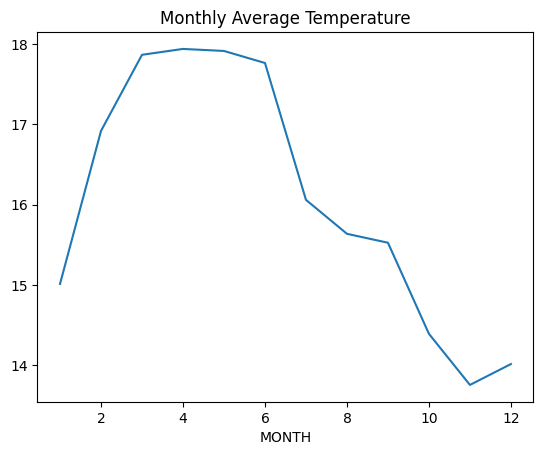

In [15]:
monthly_temp = df.groupby("MONTH")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.show()

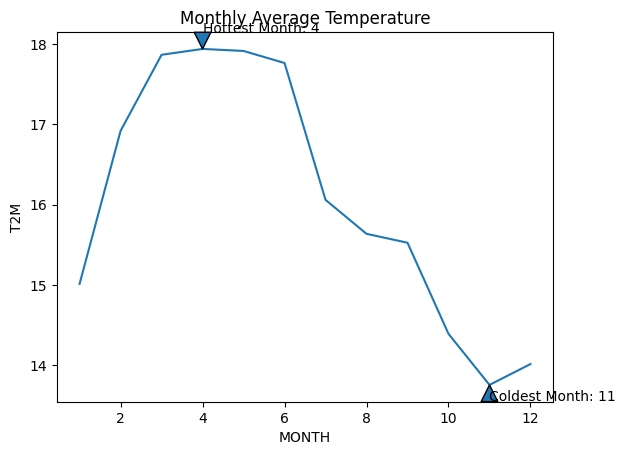

In [16]:
max_month = monthly_temp.idxmax()
min_month = monthly_temp.idxmin()

max_value = monthly_temp.max()
min_value = monthly_temp.min()

plt.figure()
monthly_temp.plot(kind="line")

# Annotating hottest month
plt.annotate(
    f"Hottest Month: {max_month}",
    xy=(max_month, max_value),
    xytext=(max_month, max_value + 0.2),
    arrowprops=dict()
)

# Annotating coldest month
plt.annotate(
    f"Coldest Month: {min_month}",
    xy=(min_month, min_value),
    xytext=(min_month, min_value - 0.2),
    arrowprops=dict()
)

plt.title("Monthly Average Temperature")
plt.xlabel("MONTH")
plt.ylabel("T2M")
plt.show()

The monthly temperature trend shows a clear seasonal pattern. The highest average temperatures occur in month 4(April).While the lowest occur in November(month 11)

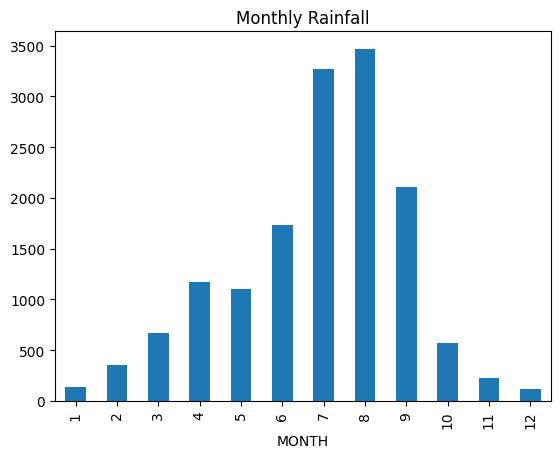

In [17]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

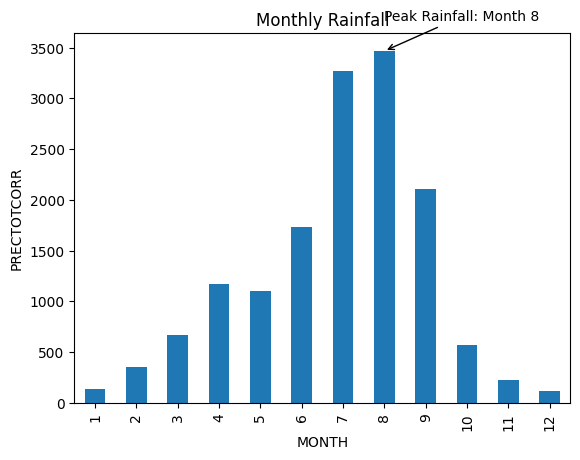

In [18]:
max_month = monthly_rain.idxmax()
max_value = monthly_rain.max()

plt.figure()
ax = monthly_rain.plot(kind="bar")

x_pos = max_month - 1

ax.annotate(
    f"Peak Rainfall: Month {max_month}",
    xy=(x_pos, max_value),
    xytext=(x_pos, max_value + 300),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly Rainfall")
plt.xlabel("MONTH")
plt.ylabel("PRECTOTCORR")
plt.show()

The rainfall pattern shows a strong seasonal trend, with precipitation gradually increasing from March and peaking sharply in August. The period between June and September represents the main rainy seasons. After September, rainfall declines rapidly. After which, there is a prolonged dry period from the period of November to February (precipiation levels are lower). 
No major anomalies are observed, as the pattern follows a consistent seasonal cycle.

Correlation & Relationship Analysis

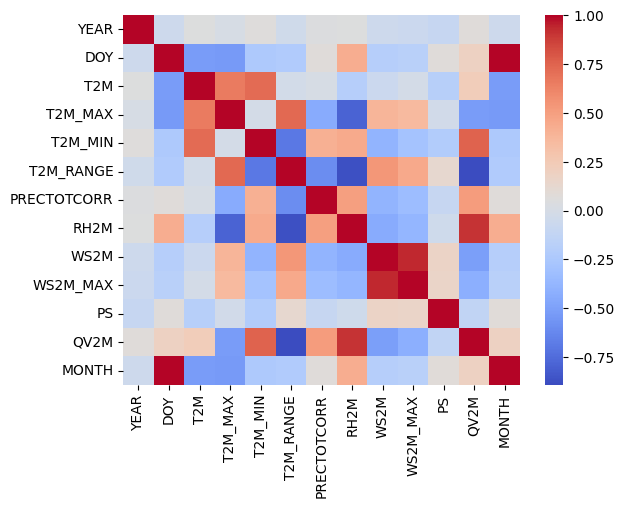

In [20]:
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

<Axes: xlabel='T2M', ylabel='RH2M'>

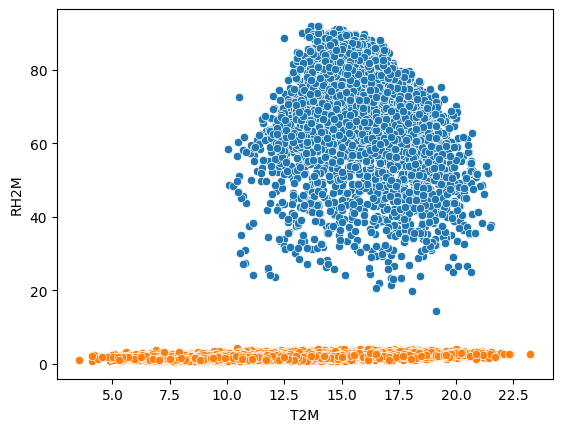

In [21]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)

The correlation analysis reveals that there are three strong relationships between climate variables.

To begin with,  there is a very strong positive correlation between WS2M and WS2M_MAX. This means that high wind speed averages are highly positively correlated with maximum wind speeds. The correlation was predictable since the two climate variables represent different measures of wind characteristics.

Secondly, T2M has a high positive correlation with T2M_MAX. In this case, an increase in the average temperature implies that the maximum daily temperature rises.

Finally, the correlation analysis shows a negative correlation between T2M and RH2M. From the above it can be deduced that, high temperatures were generally associated with lower relative  humidity values.

Distribution Analysis

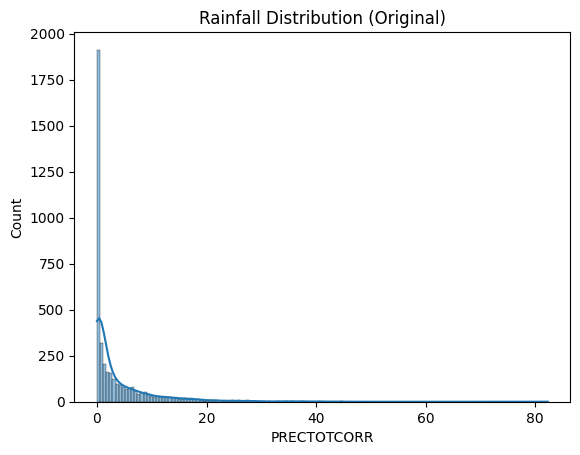

In [23]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.title("Rainfall Distribution (Original)")
plt.show()

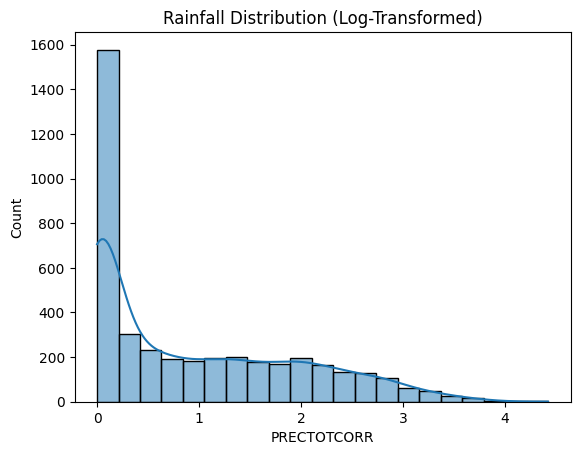

In [24]:
sns.histplot(np.log1p(df["PRECTOTCORR"]), kde=True)
plt.title("Rainfall Distribution (Log-Transformed)")
plt.show()

The distribution of rainfall is highly right-skewed, with most observations concentrated near zero and a long tail representing occasional high rainfall events.  The skewness implies that rainfall does not happen often but tends to be severe when it rains.

A logarithmic transformation was performed to represent the rainfall data, and to better visualize the distribution. As a result, it can be observed that most days have light precipitation levels, and heavy rainfall is an uncommon event.

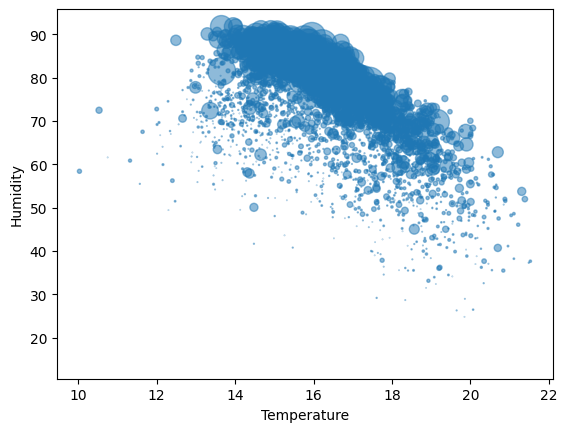

In [25]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()